In [1]:
#----------------------------------------------
# https://huggingface.co/sanzofr/Stable-difusion
#--------------------------------------------------
import torch
from diffusers import StableDiffusionPipeline

model_id = "CompVis/stable-diffusion-v1-4"
device = "cuda"


pipe = StableDiffusionPipeline.from_pretrained(model_id, torch_dtype=torch.float16)
pipe = pipe.to(device)

prompt = "a photo of an astronaut riding a horse on mars"
image = pipe(prompt).images[0]

image.save("astronaut_rides_horse.png")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/541 [00:00<?, ?B/s]

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

merges.txt: 0.00B [00:00, ?B/s]

scheduler_config-checkpoint.json:   0%|          | 0.00/209 [00:00<?, ?B/s]

...

vae/diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

unet/diffusion_pytorch_model.safetensors:   0%|          | 0.00/3.44G [00:00<?, ?B/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

`torch_dtype` is deprecated! Use `dtype` instead!


  0%|          | 0/50 [00:00<?, ?it/s]

## [2] 최신 생성 모델들(Stable Diffusion, DALL-E 등)은
-  두 기술을 결합하여 사용합니다. VAE로 이미지를 압축된 잠재 공간으로 변환하고,
- 그 공간에서 디퓨전 모델을 적용하여 각각의 장점을 활용하는 방식입니다.

            Latent Diffusion Model (LDM)의 작동 방식:
            VAE의 역할 (압축 단계):

            고해상도 이미지(예: 512×512)를 저차원 잠재 공간(예: 64×64)으로 압축
            이미지의 핵심 정보는 유지하면서 불필요한 세부사항 제거
            계산 효율성을 크게 향상

            디퓨전 모델의 역할 (생성 단계):
            압축된 잠재 공간에서 노이즈 제거 과정 수행
            텍스트 프롬프트 조건을 반영하여 원하는 이미지 생성
            픽셀 공간이 아닌 잠재 공간에서 작동하므로 훨씬 빠름


            VAE 디코더 (복원 단계):
            생성된 잠재 표현을 다시 고해상도 이미지로 변환

            이 결합의 장점:
            효율성: 전체 이미지가 아닌 압축된 표현에서 작업하므로 GPU 메모리와 계산량 대폭 감소
            품질: 디퓨전의 우수한 생성 품질 유지
            속도: 저차원 공간에서 작업하므로 순수 픽셀 기반 디퓨전보다 훨씬 빠름
            이것이 Stable Diffusion이 "Latent Diffusion"이라고 불리는 이유입니다!

##  Stable Diffusion의 핵심 원리
 Stable Diffusion = Latent Diffusion Model (LDM)
1. VAE 학습 (20 epochs) → 이미지 압축/복원 학습
2. Diffusion 학습 (30 epochs) → 잠재공간에서 노이즈 제거 학습  
3. 샘플 생성 → 노이즈에서 이미지 생성

                            이코드,              원래 stable Diffusion
          VAE            28×28 → 64차원        512×512 → 64×64
          Diffusion       ResBlock × 4          U-Net (Attention 포함)
          조건없음         (무조건 생성)         Text Encoder (CLIP)
          Timesteps         1000단계                 1000단계
          샘플링             DDPM                     DDIM/DDPM
*참고: CLIP Text Encoder란?
CLIP(Contrastive Language-Image Pre-training)의 텍스트 인코더는 텍스트를 벡터로 변환하는 모델입니다.
4억 개의 (이미지, 텍스트) 쌍으로 학습

          Diffusion Models (큰 범주)
              ├─ DDPM (2020) ← 원조!      (1000 단계,느림)
              ├─ DDIM (2021) ← 빠른 버전 (50단계로 줄임)
              ├─ Latent Diffusion (2021) ← Stable Diffusion
              ├─ Consistency Models (2023)
              └─ Flow Matching (2022)

Using device: cuda


100%|██████████| 9.91M/9.91M [00:01<00:00, 5.53MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 127kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.19MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 9.27MB/s]


=== Training VAE ===


Epoch 1/20, VAE Loss: 33.3504
Epoch 2/20, VAE Loss: 12.7590
Epoch 3/20, VAE Loss: 11.6647
Epoch 4/20, VAE Loss: 11.1136
Epoch 5/20, VAE Loss: 10.7660
Epoch 6/20, VAE Loss: 10.5256
Epoch 7/20, VAE Loss: 10.3294
Epoch 8/20, VAE Loss: 10.1684
Epoch 9/20, VAE Loss: 10.0399
Epoch 10/20, VAE Loss: 9.9356
Epoch 11/20, VAE Loss: 9.8472
Epoch 12/20, VAE Loss: 9.7755
Epoch 13/20, VAE Loss: 9.6921
Epoch 14/20, VAE Loss: 9.6488
Epoch 15/20, VAE Loss: 9.5863
Epoch 16/20, VAE Loss: 9.5325
Epoch 17/20, VAE Loss: 9.4839
Epoch 18/20, VAE Loss: 9.4307
Epoch 19/20, VAE Loss: 9.4045
Epoch 20/20, VAE Loss: 9.3619

=== Training Diffusion ===
Epoch 1/30, Diffusion Loss: 0.783822
Epoch 2/30, Diffusion Loss: 0.585200
Epoch 3/30, Diffusion Loss: 0.550787
Epoch 4/30, Diffusion Loss: 0.520892
Epoch 5/30, Diffusion Loss: 0.514044
  Generating samples...
Epoch 6/30, Diffusion Loss: 0.507387
Epoch 7/30, Diffusion Loss: 0.507711
Epoch 8/30, Diffusion Loss: 0.501579
Epoch 9/30, Diffusion Loss: 0.498868
Epoch 10/30, Di

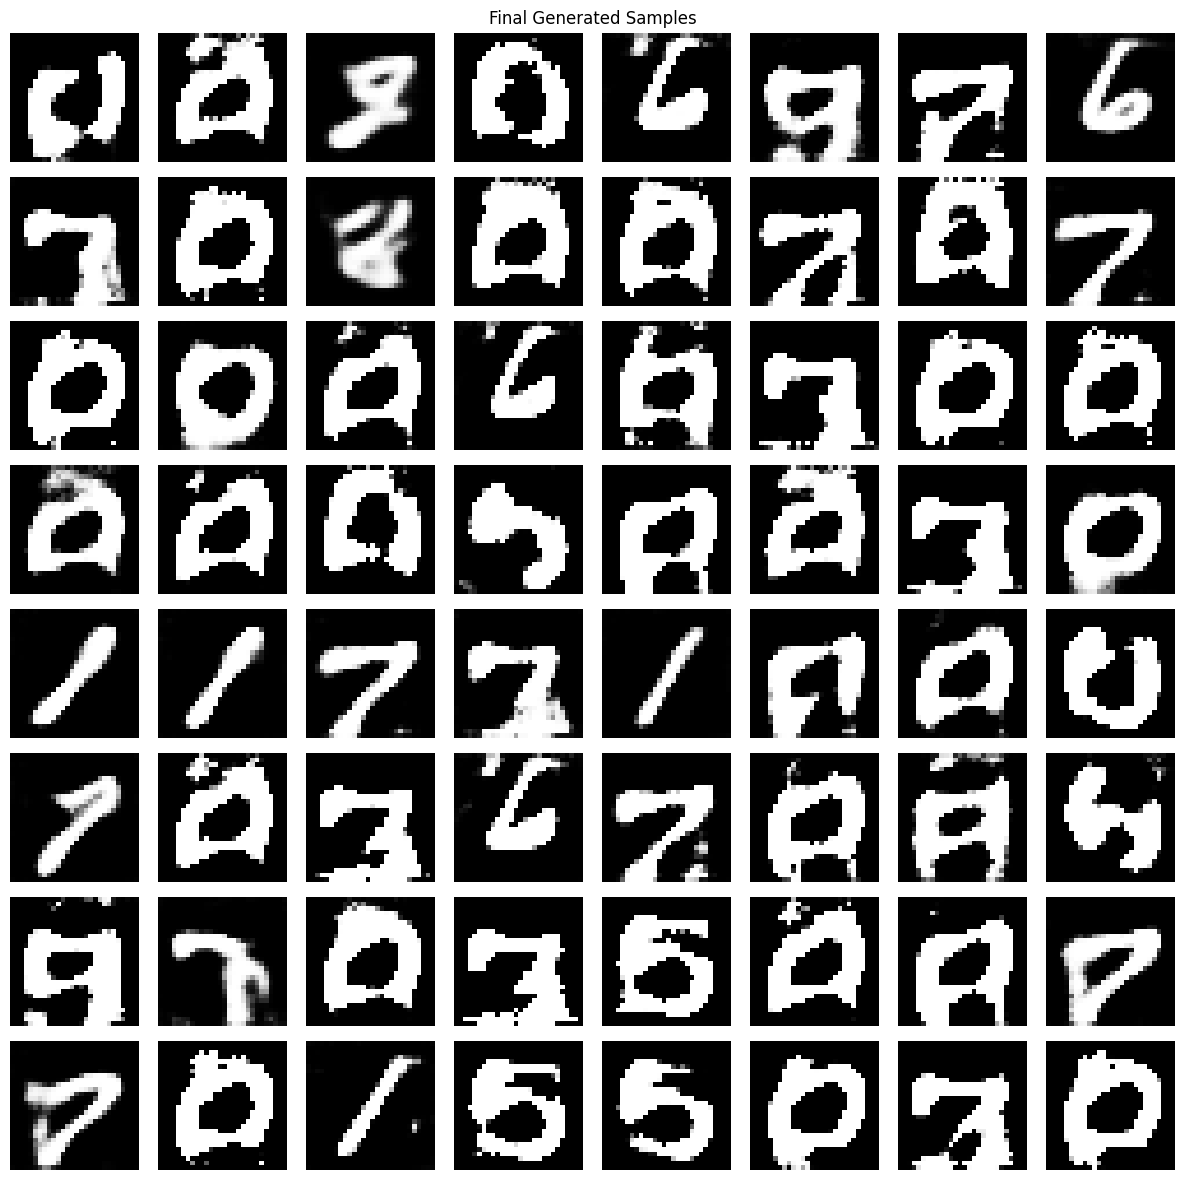

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import numpy as np

# 1. 개선된 VAE
class ImprovedVAE(nn.Module):
    def __init__(self, latent_dim=64):
        super().__init__()
        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, 4, stride=2, padding=1),   # 28x28 -> 14x14
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2),
            nn.Conv2d(32, 64, 4, stride=2, padding=1),  # 14x14 -> 7x7
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2),
            nn.Conv2d(64, 128, 3, stride=1, padding=1), # 7x7 -> 7x7
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2),
        )
        self.fc_mu = nn.Linear(128 * 7 * 7, latent_dim)
        self.fc_logvar = nn.Linear(128 * 7 * 7, latent_dim)

        # Decoder
        self.fc_decode = nn.Linear(latent_dim, 128 * 7 * 7)
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(128, 64, 3, stride=1, padding=1),  # 7x7 -> 7x7
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),   # 7x7 -> 14x14
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, 4, stride=2, padding=1),    # 14x14 -> 28x28
            nn.Sigmoid()
        )

    def encode(self, x):
        h = self.encoder(x)
        h = h.view(h.size(0), -1)
        return self.fc_mu(h), self.fc_logvar(h)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.fc_decode(z)
        h = h.view(h.size(0), 128, 7, 7)
        return self.decoder(h)

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

# 2. U-Net 스타일 Diffusion Model
class TimeEmbedding(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, t):
        half_dim = self.dim // 2
        emb = np.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=t.device) * -emb)
        emb = t[:, None] * emb[None, :]
        emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=-1)
        return emb

class ResBlock(nn.Module):
    def __init__(self, dim, time_dim):
        super().__init__()
        self.time_mlp = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_dim, dim)
        )
        self.block1 = nn.Sequential(
            nn.Linear(dim, dim),
            nn.SiLU(),
        )
        self.block2 = nn.Sequential(
            nn.Linear(dim, dim),
            nn.SiLU(),
        )

    def forward(self, x, t):
        h = self.block1(x)
        h = h + self.time_mlp(t)
        h = self.block2(h)
        return x + h

class ImprovedDiffusion(nn.Module):
    def __init__(self, latent_dim=64, hidden_dim=256, time_dim=128):
        super().__init__()
        self.time_embed = TimeEmbedding(time_dim)

        self.input_proj = nn.Linear(latent_dim, hidden_dim)

        self.blocks = nn.ModuleList([
            ResBlock(hidden_dim, time_dim),
            ResBlock(hidden_dim, time_dim),
            ResBlock(hidden_dim, time_dim),
            ResBlock(hidden_dim, time_dim),
        ])

        self.output_proj = nn.Linear(hidden_dim, latent_dim)

    def forward(self, z, t):
        t_emb = self.time_embed(t)
        h = self.input_proj(z)

        for block in self.blocks:
            h = block(h, t_emb)

        return self.output_proj(h)

# 3. Cosine 노이즈 스케줄
def cosine_beta_schedule(timesteps, s=0.008):
    steps = timesteps + 1
    x = torch.linspace(0, timesteps, steps)
    alphas_cumprod = torch.cos(((x / timesteps) + s) / (1 + s) * torch.pi * 0.5) ** 2
    alphas_cumprod = alphas_cumprod / alphas_cumprod[0]
    betas = 1 - (alphas_cumprod[1:] / alphas_cumprod[:-1])
    return torch.clip(betas, 0.0001, 0.9999)

# 4. 개선된 Latent Diffusion
class ImprovedLatentDiffusion:
    def __init__(self, vae, diffusion_model, timesteps=1000, device='cpu'):
        self.vae = vae
        self.diffusion = diffusion_model
        self.timesteps = timesteps
        self.device = device

        # Cosine schedule - GPU로 이동
        self.betas = cosine_beta_schedule(timesteps).to(device)
        self.alphas = 1 - self.betas
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0)

    def add_noise(self, z, t):
        """개선된 노이즈 추가"""
        noise = torch.randn_like(z)

        # t는 timestep 인덱스 (0~timesteps-1) - 이미 device에 있음
        sqrt_alphas_cumprod_t = torch.sqrt(self.alphas_cumprod[t])
        sqrt_one_minus_alphas_cumprod_t = torch.sqrt(1 - self.alphas_cumprod[t])

        return (sqrt_alphas_cumprod_t.view(-1, 1) * z +
                sqrt_one_minus_alphas_cumprod_t.view(-1, 1) * noise), noise

    def train_step(self, images, optimizer):
        """Diffusion 학습 스텝"""
        self.diffusion.train()
        optimizer.zero_grad()

        # VAE로 잠재 공간으로 인코딩
        with torch.no_grad():
            mu, logvar = self.vae.encode(images)
            z = self.vae.reparameterize(mu, logvar)

        # 랜덤 타임스텝 (정수) - device에 직접 생성
        t = torch.randint(0, self.timesteps, (z.size(0),), device=self.device)

        # 노이즈 추가
        z_noisy, noise = self.add_noise(z, t)

        # 노이즈 예측 (t를 0~1 사이로 정규화)
        t_normalized = t.float() / self.timesteps
        predicted_noise = self.diffusion(z_noisy, t_normalized)

        # Loss 계산
        loss = F.mse_loss(predicted_noise, noise)
        loss.backward()
        optimizer.step()

        return loss.item()

    @torch.no_grad()
    def sample(self, n_samples=16):
        """DDPM 샘플링"""
        self.diffusion.eval()
        self.vae.eval()

        # 랜덤 노이즈에서 시작
        z = torch.randn(n_samples, self.vae.fc_mu.out_features, device=self.device)

        # Reverse diffusion process
        for i in reversed(range(self.timesteps)):
            t = torch.ones(n_samples, device=self.device) * i
            t_normalized = t / self.timesteps

            # 노이즈 예측
            predicted_noise = self.diffusion(z, t_normalized)

            # DDPM 업데이트
            alpha_t = self.alphas[i]
            alpha_cumprod_t = self.alphas_cumprod[i]
            beta_t = self.betas[i]

            if i > 0:
                noise = torch.randn_like(z)
            else:
                noise = torch.zeros_like(z)

            z = (1 / torch.sqrt(alpha_t)) * (
                z - ((1 - alpha_t) / torch.sqrt(1 - alpha_cumprod_t)) * predicted_noise
            ) + torch.sqrt(beta_t) * noise

        # VAE 디코더로 이미지 복원
        images = self.vae.decode(z)
        return images

# 5. 학습 코드
def train():
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Using device: {device}")

    # 데이터 로드
    transform = transforms.Compose([
        transforms.ToTensor(),
    ])
    train_dataset = datasets.MNIST('./data', train=True, download=True, transform=transform)
    train_loader = DataLoader(train_dataset, batch_size=256, shuffle=True, num_workers=2)

    # 모델 초기화
    latent_dim = 64
    vae = ImprovedVAE(latent_dim=latent_dim).to(device)
    diffusion_model = ImprovedDiffusion(latent_dim=latent_dim, hidden_dim=256).to(device)

    # VAE 먼저 학습
    print("\n=== Training VAE ===")
    vae_optimizer = torch.optim.AdamW(vae.parameters(), lr=5e-4, weight_decay=1e-4)

    for epoch in range(20):
        total_loss = 0
        for images, _ in train_loader:
            images = images.to(device)

            recon, mu, logvar = vae(images)
            recon_loss = F.mse_loss(recon, images, reduction='sum')
            kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
            loss = recon_loss + 0.1 * kld_loss

            vae_optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(vae.parameters(), 1.0)
            vae_optimizer.step()

            total_loss += loss.item()

        avg_loss = total_loss / len(train_loader.dataset)
        print(f"Epoch {epoch+1}/20, VAE Loss: {avg_loss:.4f}")

        # 중간 결과 확인
        if (epoch + 1) % 5 == 0:
            with torch.no_grad():
                sample_images = images[:16]
                recon_images, _, _ = vae(sample_images)

                fig, axes = plt.subplots(2, 8, figsize=(12, 3))
                for i in range(8):
                    axes[0, i].imshow(sample_images[i].cpu().squeeze(), cmap='gray')
                    axes[0, i].axis('off')
                    axes[1, i].imshow(recon_images[i].cpu().squeeze(), cmap='gray')
                    axes[1, i].axis('off')
                plt.suptitle(f'VAE Epoch {epoch+1} - Top: Original, Bottom: Reconstructed')
                plt.tight_layout()
                plt.savefig(f'vae_epoch_{epoch+1}.png')
                plt.close()

    # Diffusion 학습
    print("\n=== Training Diffusion ===")
    ld = ImprovedLatentDiffusion(vae, diffusion_model, timesteps=1000, device=device)
    diffusion_optimizer = torch.optim.AdamW(diffusion_model.parameters(), lr=1e-4, weight_decay=1e-4)

    for epoch in range(30):
        total_loss = 0
        for images, _ in train_loader:
            images = images.to(device)
            loss = ld.train_step(images, diffusion_optimizer)
            total_loss += loss

        avg_loss = total_loss / len(train_loader)
        print(f"Epoch {epoch+1}/30, Diffusion Loss: {avg_loss:.6f}")

        # 샘플 생성 (5 epoch마다)
        if (epoch + 1) % 5 == 0:
            print(f"  Generating samples...")
            samples = ld.sample(n_samples=16)

            fig, axes = plt.subplots(4, 4, figsize=(8, 8))
            for i, ax in enumerate(axes.flat):
                ax.imshow(samples[i].cpu().squeeze(), cmap='gray')
                ax.axis('off')
            plt.suptitle(f'Diffusion Epoch {epoch+1}')
            plt.tight_layout()
            plt.savefig(f'diffusion_epoch_{epoch+1}.png')
            plt.close()

    # 최종 샘플 생성
    print("\n=== Generating Final Samples ===")
    samples = ld.sample(n_samples=64)

    fig, axes = plt.subplots(8, 8, figsize=(12, 12))
    for i, ax in enumerate(axes.flat):
        ax.imshow(samples[i].cpu().squeeze(), cmap='gray')
        ax.axis('off')
    plt.suptitle('Final Generated Samples')
    plt.tight_layout()
    plt.savefig('final_samples.png', dpi=150)
    print("Final samples saved to 'final_samples.png'")

    # 모델 저장
    torch.save({
        'vae': vae.state_dict(),
        'diffusion': diffusion_model.state_dict(),
    }, 'mnist_latent_diffusion.pth')
    print("Model saved to 'mnist_latent_diffusion.pth'")

if __name__ == "__main__":
    train()